# Asset Health Monitoring
## Notebook 03 - Model Development & Health Scoring

**Input:** `data/processed/features.parquet`  
**Output:**
- `models/isolation_forest.pkl` — trained anomaly detection model
- `models/one_class_svm.pkl` — baseline comparison model
- `data/processed/scored.parquet` — dataset with anomaly scores + health scores

### Pipeline
1. Load features
2. Train Isolation Forest (unsupervised, pada data normal)
3. Train One-Class SVM (baseline)
4. Evaluate kedua model vs failure ground truth
5. Lead time analysis (berapa jam sebelum failure anomali terdeteksi?)
6. Compute Asset Health Score (0-100)
7. Save models + scored dataset


In [1]:
import os
# Auto-detect root: works both in Jupyter and nbconvert
try:
    ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Jupyter kernel: __file__ tidak ada, pakai getcwd()
    ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_DIR    = os.path.join(ROOT, 'data', 'raw')
PROC_DIR    = os.path.join(ROOT, 'data', 'processed')
MODELS_DIR  = os.path.join(ROOT, 'models')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')

for d in [PROC_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'ROOT       : {ROOT}')
print(f'DATA_DIR   : {DATA_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')


ROOT       : /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring
DATA_DIR   : /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring/data/raw
FIGURES_DIR: /Users/aryautomo/Documents/6th Term/EDM/Project/asset-health-monitoring/reports/figures


## 0. Setup

In [2]:
import os, warnings, joblib, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              roc_auc_score)

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "axes.grid":True,"grid.alpha":0.3,"grid.linestyle":"--",
    "font.size":11,"axes.titlesize":13,"axes.titleweight":"bold","figure.dpi":120
})

PROC_DIR    = os.path.join(ROOT, 'data', 'processed')
MODELS_DIR  = os.path.join(ROOT, 'models')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')

def save_fig(fig, name):
    fig.savefig(f'{FIGURES_DIR}/{name}.png', dpi=150, bbox_inches='tight')
    print(f'  Saved -> reports/figures/{name}.png')
    plt.show()

print('Setup complete')


Setup complete


## 1. Load Processed Features

In [3]:
df = pd.read_parquet(f'{PROC_DIR}/features.parquet')

# Load feature columns & scaler from preprocessing
with open(f'{MODELS_DIR}/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

artifact = joblib.load(f'{MODELS_DIR}/scaler.pkl')
scaler   = artifact['scaler']

print(f'Dataset shape  : {df.shape}')
print(f'Feature columns: {len(FEATURE_COLS)}')
print(f'Machines       : {df["machineID"].nunique()}')
print(f'Date range     : {df["datetime"].min().date()} -> {df["datetime"].max().date()}')
print(f'Failure rows 24h: {df["will_fail_24h"].sum():,} / {len(df):,} ({df["will_fail_24h"].mean()*100:.2f}%)')


Dataset shape  : (876100, 96)
Feature columns: 44
Machines       : 100
Date range     : 2015-01-01 -> 2016-01-01
Failure rows 24h: 17,902 / 876,100 (2.04%)


## 2. Train/Test Split

**Strategi:** time-based split. Jan-Sep 2015 untuk training, Oct-Dec untuk testing.
Ini menghindari data leakage temporal yang umum pada time series.

Isolation Forest dilatih **hanya pada data normal** (tidak ada failure dalam 72 jam ke depan).
Model harus belajar definisi 'normal' tanpa melihat anomali sama sekali.


In [4]:
SPLIT_DATE  = '2015-10-01'
TRAIN_MASK  = df['datetime'] <  SPLIT_DATE
TEST_MASK   = df['datetime'] >= SPLIT_DATE

# Training: hanya data normal (tidak akan fail dalam 72 jam ke depan)
NORMAL_MASK = df['hours_to_failure'] > 72

df_train_normal = df[TRAIN_MASK & NORMAL_MASK]
df_test         = df[TEST_MASK]

# Get scaled features
SCALED_COLS = [f'{c}_scaled' for c in FEATURE_COLS]
X_train = df_train_normal[SCALED_COLS].values
X_test  = df_test[SCALED_COLS].values
y_test  = df_test['will_fail_24h'].values

print(f'Training set (normal only): {len(X_train):,} rows')
print(f'Test set                  : {len(X_test):,} rows')
print(f'Test positive rate (24h)  : {y_test.mean()*100:.2f}%')


Training set (normal only): 615,203 rows
Test set                  : 221,500 rows
Test positive rate (24h)  : 1.91%


## 3. Isolation Forest

**Cara kerja:** Isolation Forest secara random membagi data menggunakan decision trees.
Anomali lebih mudah 'diisolasi' karena mereka jauh dari mayoritas data — butuh lebih sedikit splits.
Score = rata-rata kedalaman isolasi. Makin dangkal = makin anomali.

**Parameter kunci:**
- `contamination=0.05`: ekspektasi 5% data adalah anomali (tuning point)
- `n_estimators=200`: lebih banyak trees = lebih stabil, lebih lambat


In [5]:
print('Training Isolation Forest...')

IF_model = IsolationForest(
    n_estimators  = 200,
    contamination = 0.05,   # tuning: coba 0.03, 0.05, 0.08
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
IF_model.fit(X_train)
print('Training complete.')

# Score seluruh dataset
X_all = df[SCALED_COLS].fillna(0).values
df['if_score']     = IF_model.decision_function(X_all)  # raw score, higher=more normal
df['if_anomaly']   = IF_model.predict(X_all)            # -1=anomaly, 1=normal
df['if_anomaly_01']= (df['if_anomaly'] == -1).astype(int)

print(f'Anomalies detected in full dataset: {df["if_anomaly_01"].sum():,}')
print(f'({df["if_anomaly_01"].mean()*100:.1f}% of all rows)')


Training Isolation Forest...


Training complete.


Anomalies detected in full dataset: 63,771
(7.3% of all rows)


## 4. One-Class SVM (Baseline)

One-Class SVM mencari hyperplane yang memisahkan data normal dari asal koordinat.
Lebih lambat dari IF tapi bisa menangkap non-linear boundaries lebih baik.
Di sini digunakan sebagai perbandingan.

*Catatan: OCSVM lambat pada data besar — subsample 20.000 baris untuk training.*


In [6]:
print('Training One-Class SVM (subsampled)...')

# Subsample untuk efisiensi (OCSVM O(n^2) complexity)
np.random.seed(42)
n_subsample = min(20000, len(X_train))
idx_sub     = np.random.choice(len(X_train), n_subsample, replace=False)
X_train_sub = X_train[idx_sub]

SVM_model = OneClassSVM(
    kernel = 'rbf',
    nu     = 0.05,   # mirip contamination di IF
    gamma  = 'scale'
)
SVM_model.fit(X_train_sub)
print('Training complete.')

# Score test set
df.loc[TEST_MASK, 'svm_score']      = SVM_model.decision_function(X_test)
df.loc[TEST_MASK, 'svm_anomaly']    = SVM_model.predict(X_test)
df.loc[TEST_MASK, 'svm_anomaly_01'] = (df.loc[TEST_MASK,'svm_anomaly'] == -1).astype(int)
df['svm_anomaly_01'] = df['svm_anomaly_01'].fillna(0)

print(f'SVM anomalies in test set: {df.loc[TEST_MASK,"svm_anomaly_01"].sum():,}')


Training One-Class SVM (subsampled)...


Training complete.


SVM anomalies in test set: 15,708.0


## 5. Model Evaluation

Evaluasi menggunakan `will_fail_24h` sebagai ground truth.
Karena ini unsupervised, kita tidak expect perfect accuracy —
yang penting adalah apakah anomali terdeteksi SEBELUM failure terjadi.


In [7]:
def evaluate_model(y_true, y_pred, scores, model_name):
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal','Pre-failure']))
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion matrix:')
    print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
    print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
    if scores is not None:
        # Flip sign: higher score = more anomalous for PR curve
        s_flipped = -scores
        ap = average_precision_score(y_true, s_flipped)
        print(f'Average Precision: {ap:.4f}')
    return cm

# Evaluation on test set
y_true_test   = df.loc[TEST_MASK, 'will_fail_24h'].values
y_pred_if     = df.loc[TEST_MASK, 'if_anomaly_01'].values
y_pred_svm    = df.loc[TEST_MASK, 'svm_anomaly_01'].values
scores_if     = df.loc[TEST_MASK, 'if_score'].values
scores_svm    = df.loc[TEST_MASK, 'svm_score'].values

cm_if  = evaluate_model(y_true_test, y_pred_if,  scores_if,  'Isolation Forest')
cm_svm = evaluate_model(y_true_test, y_pred_svm, scores_svm, 'One-Class SVM')



  Isolation Forest
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    217279
 Pre-failure       0.25      0.96      0.40      4221

    accuracy                           0.95    221500
   macro avg       0.63      0.95      0.69    221500
weighted avg       0.98      0.95      0.96    221500

Confusion matrix:
  TN=205,413  FP=11,866
  FN=188  TP=4,033
Average Precision: 0.6421

  One-Class SVM
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    217279
 Pre-failure       0.26      0.95      0.40      4221

    accuracy                           0.95    221500
   macro avg       0.63      0.95      0.69    221500
weighted avg       0.98      0.95      0.96    221500

Confusion matrix:
  TN=205,594  FP=11,685
  FN=198  TP=4,023
Average Precision: 0.7096


  Saved -> reports/figures/09_model_evaluation.png


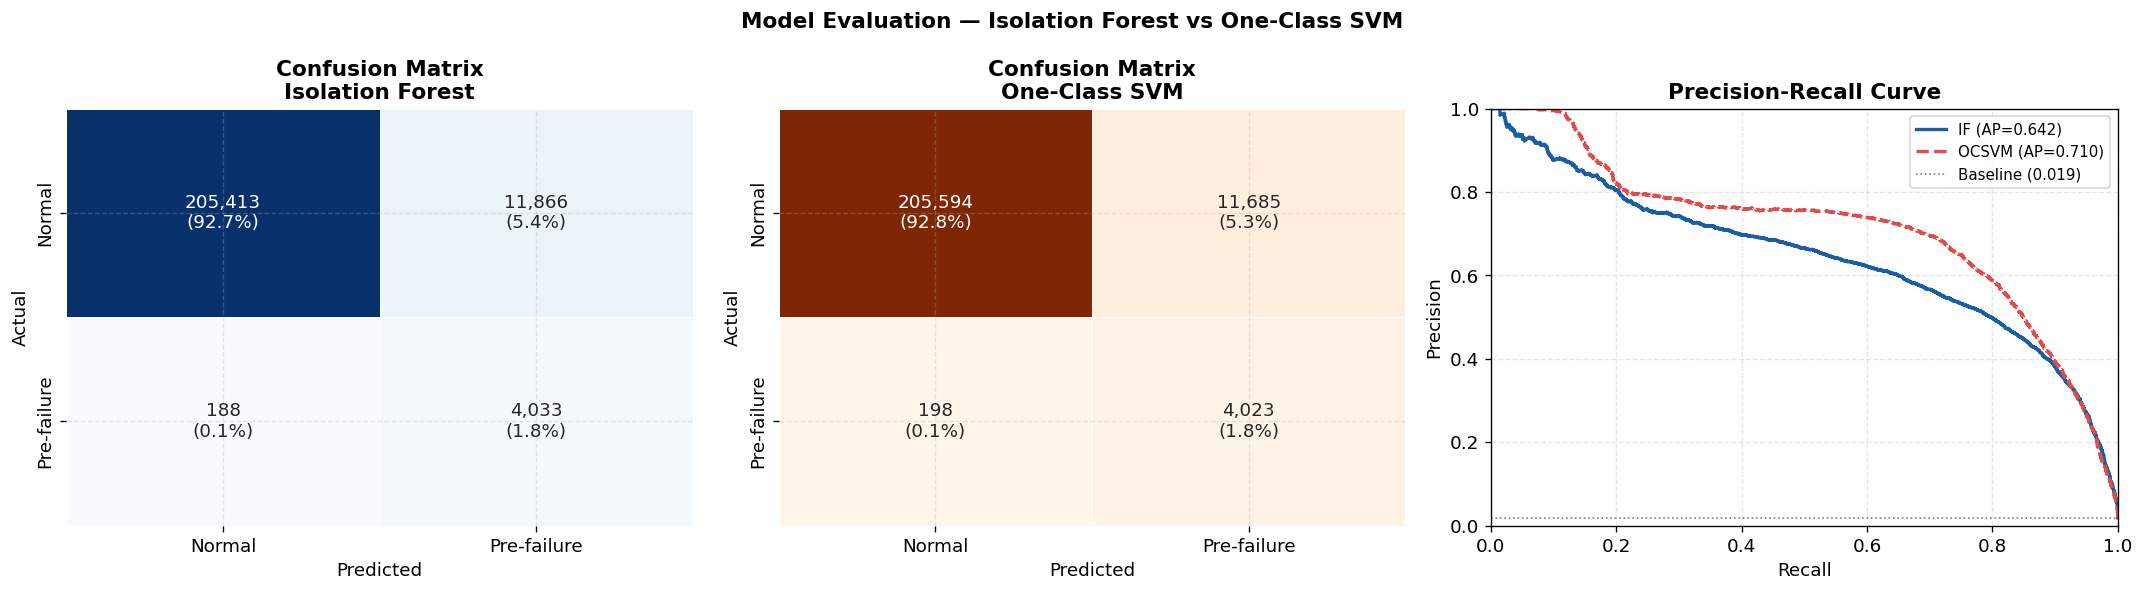

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — Isolation Forest vs One-Class SVM',
             fontsize=13, fontweight='bold')

# Confusion matrices
for ax, cm, name, color in zip(
    axes[:2],
    [cm_if, cm_svm],
    ['Isolation Forest','One-Class SVM'],
    ['Blues','Oranges']
):
    cm_pct = cm / cm.sum() * 100
    annot  = [[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)]
    sns.heatmap(cm, ax=ax, annot=np.array(annot), fmt='',
                cmap=color, linewidths=0.5,
                xticklabels=['Normal','Pre-failure'],
                yticklabels=['Normal','Pre-failure'],
                cbar=False)
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# Precision-Recall curve (Isolation Forest)
prec, rec, thresh = precision_recall_curve(y_true_test, -scores_if)
ap = average_precision_score(y_true_test, -scores_if)
axes[2].plot(rec, prec, color='#185FA5', linewidth=2, label=f'IF (AP={ap:.3f})')
prec_s, rec_s, _ = precision_recall_curve(y_true_test, -scores_svm)
ap_s = average_precision_score(y_true_test, -scores_svm)
axes[2].plot(rec_s, prec_s, color='#E24B4A', linewidth=2, linestyle='--',
             label=f'OCSVM (AP={ap_s:.3f})')
baseline = y_true_test.mean()
axes[2].axhline(baseline, color='gray', linestyle=':', linewidth=1,
                label=f'Baseline ({baseline:.3f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(fontsize=9); axes[2].set_xlim(0,1); axes[2].set_ylim(0,1)

plt.tight_layout()
save_fig(fig, '09_model_evaluation')


## 6. Lead Time Analysis

**Pertanyaan utama:** Berapa jam sebelum failure model mulai mendeteksi anomali?

Ini adalah insight paling valuable untuk stakeholder — bukan hanya 'model bisa detect',
tapi 'model memberikan X jam peringatan dini untuk tindakan preventif'.


In [9]:
print('Computing lead time analysis...')

HOURS_BEFORE = 96  # window analisis

lead_times   = []
detection_rates = {h: 0 for h in [6,12,24,48,72]}
n_failures   = 0

failures_raw = pd.read_csv('../data/raw/PdM_failures.csv', parse_dates=['datetime'])

for _, frow in failures_raw.iterrows():
    mid, ft = frow['machineID'], frow['datetime']
    window_mask = (
        (df['machineID'] == mid) &
        (df['datetime']  >= ft - pd.Timedelta(hours=HOURS_BEFORE)) &
        (df['datetime']  <= ft)
    )
    pre_df = df[window_mask].copy()
    if len(pre_df) == 0:
        continue
    n_failures += 1

    # Find earliest anomaly detection
    anomaly_rows = pre_df[pre_df['if_anomaly_01'] == 1]
    if len(anomaly_rows) > 0:
        earliest = anomaly_rows['datetime'].min()
        lead_h   = (ft - earliest).total_seconds() / 3600
        lead_times.append(lead_h)
        for h in detection_rates:
            if lead_h >= h:
                detection_rates[h] += 1
    else:
        lead_times.append(0)  # not detected

lead_arr = np.array(lead_times)
detected = lead_arr[lead_arr > 0]

print(f'Total failure events analyzed: {n_failures}')
print(f'Events with anomaly detected before: {len(detected)} ({len(detected)/n_failures*100:.1f}%)')
print(f'Median lead time: {np.median(detected):.1f} hours')
print(f'Mean lead time  : {np.mean(detected):.1f} hours')
print(f'Min lead time   : {np.min(detected):.1f} hours')
print(f'Max lead time   : {np.max(detected):.1f} hours')
print()
for h, cnt in detection_rates.items():
    print(f'Detected >= {h:2d}h before failure: {cnt}/{n_failures} ({cnt/n_failures*100:.1f}%)')


Computing lead time analysis...


Total failure events analyzed: 761
Events with anomaly detected before: 761 (100.0%)
Median lead time: 42.0 hours
Mean lead time  : 50.5 hours
Min lead time   : 21.0 hours
Max lead time   : 96.0 hours

Detected >=  6h before failure: 761/761 (100.0%)
Detected >= 12h before failure: 761/761 (100.0%)
Detected >= 24h before failure: 734/761 (96.5%)
Detected >= 48h before failure: 286/761 (37.6%)
Detected >= 72h before failure: 179/761 (23.5%)


  Saved -> reports/figures/10_lead_time_analysis.png


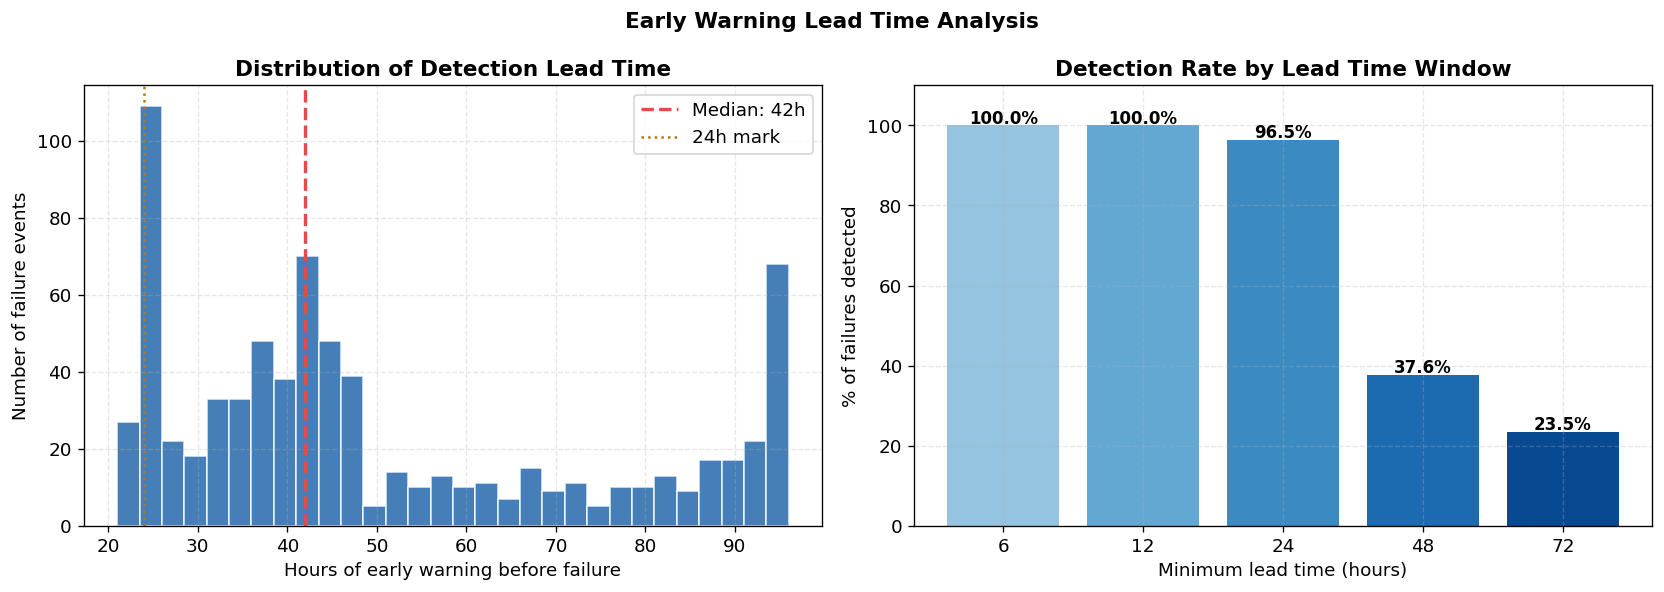

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Early Warning Lead Time Analysis', fontsize=13, fontweight='bold')

# Histogram of lead times
axes[0].hist(detected, bins=30, color='#185FA5', alpha=0.8, edgecolor='white')
axes[0].axvline(np.median(detected), color='#E24B4A', linestyle='--', linewidth=2,
                label=f'Median: {np.median(detected):.0f}h')
axes[0].axvline(24, color='#BA7517', linestyle=':', linewidth=1.5, label='24h mark')
axes[0].set_xlabel('Hours of early warning before failure')
axes[0].set_ylabel('Number of failure events')
axes[0].set_title('Distribution of Detection Lead Time')
axes[0].legend()

# Detection rate by lead time window
windows_h  = list(detection_rates.keys())
rates      = [detection_rates[h]/n_failures*100 for h in windows_h]
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(windows_h)))
bars = axes[1].bar([str(h) for h in windows_h], rates, color=colors_bar)
for bar, rate in zip(bars, rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Minimum lead time (hours)')
axes[1].set_ylabel('% of failures detected')
axes[1].set_title('Detection Rate by Lead Time Window')
axes[1].set_ylim(0, 110)

plt.tight_layout()
save_fig(fig, '10_lead_time_analysis')


## 7. Asset Health Score

Health Score adalah representasi kondisi mesin yang mudah dipahami oleh stakeholder non-teknis.

**Formula:**
```
raw_score    = decision_function(Isolation Forest)  # makin tinggi = lebih normal
normalized   = (raw_score - min) / (max - min) * 100
health_score = rolling_mean(normalized, window=6h)  # smoothing
```

**Threshold:**
- 70-100: Healthy (hijau)
- 40-69 : Warning (kuning)
- 0-39  : Critical (merah)


In [11]:
print('Computing Asset Health Score...')

# Normalize per machine (memastikan tiap mesin punya baseline yang fair)
def compute_health_score(group, window=6):
    raw   = group['if_score'].values
    g_min = raw.min()
    g_max = raw.max()
    if g_max == g_min:
        return pd.Series(50.0, index=group.index)
    normalized = (raw - g_min) / (g_max - g_min) * 100
    smoothed   = pd.Series(normalized, index=group.index)\
                   .rolling(window, min_periods=1).mean()
    return smoothed

health = df.groupby('machineID', group_keys=False).apply(compute_health_score)
df['health_score'] = health.values
df['health_score'] = df['health_score'].clip(0, 100)

# Status labels
def health_label(score):
    if score >= 70: return 'Healthy'
    elif score >= 40: return 'Warning'
    else: return 'Critical'

df['health_status'] = df['health_score'].apply(health_label)

print('Health score distribution:')
print(df['health_score'].describe().round(2))
print()
print('Health status distribution:')
print(df['health_status'].value_counts())


Computing Asset Health Score...


Health score distribution:
count    876100.00
mean         76.85
std          13.00
min           0.00
25%          72.43
50%          80.89
75%          85.53
max          97.70
Name: health_score, dtype: float64

Health status distribution:
health_status
Healthy     687753
Warning     168680
Critical     19667
Name: count, dtype: int64


  Saved -> reports/figures/11_health_score_validation.png


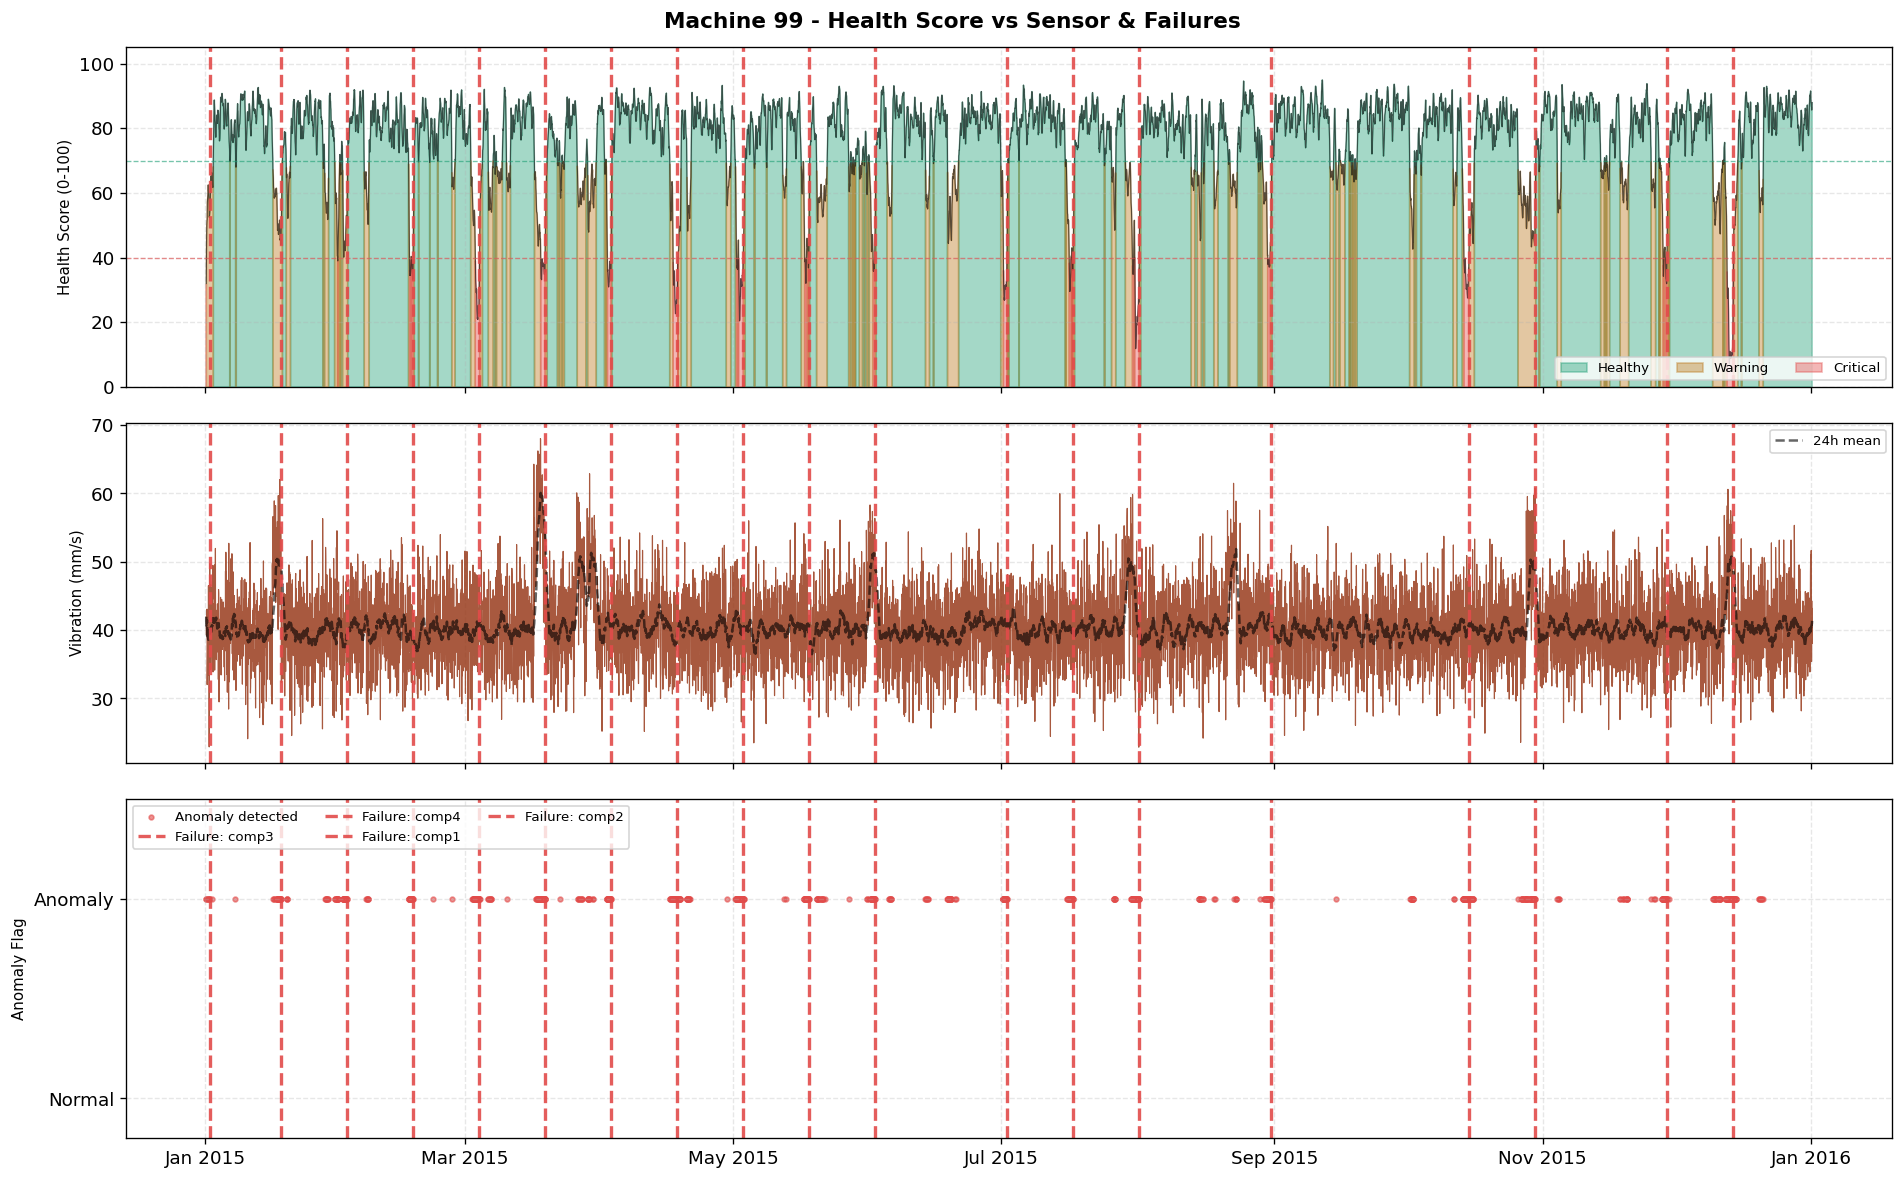

In [12]:
# Visualize health score for one machine near failure
top_machine = pd.read_csv('../data/raw/PdM_failures.csv',
                           parse_dates=['datetime'])['machineID'].value_counts().idxmax()
mdf  = df[df['machineID']==top_machine].copy()
fail_times = pd.read_csv('../data/raw/PdM_failures.csv', parse_dates=['datetime'])
fail_times = fail_times[fail_times['machineID']==top_machine]

import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Machine {top_machine} - Health Score vs Sensor & Failures',
             fontsize=13, fontweight='bold')

# Health score
ax0 = axes[0]
ax0.fill_between(mdf['datetime'], mdf['health_score'],
                 where=mdf['health_status']=='Healthy',
                 alpha=0.4, color='#1D9E75', label='Healthy')
ax0.fill_between(mdf['datetime'], mdf['health_score'],
                 where=mdf['health_status']=='Warning',
                 alpha=0.4, color='#BA7517', label='Warning')
ax0.fill_between(mdf['datetime'], mdf['health_score'],
                 where=mdf['health_status']=='Critical',
                 alpha=0.4, color='#E24B4A', label='Critical')
ax0.plot(mdf['datetime'], mdf['health_score'], color='black', linewidth=0.7, alpha=0.6)
ax0.axhline(70, color='#1D9E75', linestyle='--', linewidth=0.8, alpha=0.6)
ax0.axhline(40, color='#E24B4A', linestyle='--', linewidth=0.8, alpha=0.6)
for _, fr in fail_times.iterrows():
    ax0.axvline(fr['datetime'], color='#E24B4A', linewidth=2, linestyle='--', alpha=0.9)
ax0.set_ylabel('Health Score (0-100)', fontsize=9)
ax0.set_ylim(0, 105)
ax0.legend(fontsize=8, loc='lower right', ncol=3)

# Vibration sensor
ax1 = axes[1]
ax1.plot(mdf['datetime'], mdf['vibration'], color='#993C1D', linewidth=0.7, alpha=0.85)
ax1.plot(mdf['datetime'], mdf['vibration_mean24h'], color='black',
         linewidth=1.5, linestyle='--', alpha=0.6, label='24h mean')
for _, fr in fail_times.iterrows():
    ax1.axvline(fr['datetime'], color='#E24B4A', linewidth=2, linestyle='--', alpha=0.9)
ax1.set_ylabel('Vibration (mm/s)', fontsize=9)
ax1.legend(fontsize=8)

# Anomaly flags
ax2 = axes[2]
anomaly_rows = mdf[mdf['if_anomaly_01']==1]
ax2.scatter(anomaly_rows['datetime'], [1]*len(anomaly_rows),
            color='#E24B4A', s=8, alpha=0.6, label='Anomaly detected')
for _, fr in fail_times.iterrows():
    ax2.axvline(fr['datetime'], color='#E24B4A', linewidth=2,
                linestyle='--', alpha=0.9, label=f'Failure: {fr["failure"]}')
ax2.set_ylabel('Anomaly Flag', fontsize=9)
ax2.set_yticks([0,1])
ax2.set_yticklabels(['Normal','Anomaly'])
ax2.set_ylim(-0.2, 1.5)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(dict(zip(labels,handles)).values(), dict(zip(labels,handles)).keys(),
           fontsize=8, loc='upper left', ncol=3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
save_fig(fig, '11_health_score_validation')


## 8. Contamination Parameter Tuning

Coba beberapa nilai `contamination` dan lihat efeknya pada precision/recall.
Pilih yang memberikan keseimbangan terbaik sesuai use case:
- Rendah contamination (0.01): sedikit false alarm, tapi mungkin miss beberapa failure
- Tinggi contamination (0.10): lebih sensitif, tapi lebih banyak false alarm


Tuning contamination parameter...


  c=0.01 -> precision=0.531  recall=0.725  f1=0.613  anomalies=5,763


  c=0.03 -> precision=0.349  recall=0.917  f1=0.506  anomalies=11,080


  c=0.05 -> precision=0.256  recall=0.953  f1=0.403  anomalies=15,737


  c=0.08 -> precision=0.184  recall=0.973  f1=0.309  anomalies=22,372


  c=0.10 -> precision=0.155  recall=0.979  f1=0.267  anomalies=26,749
  Saved -> reports/figures/12_contamination_tuning.png


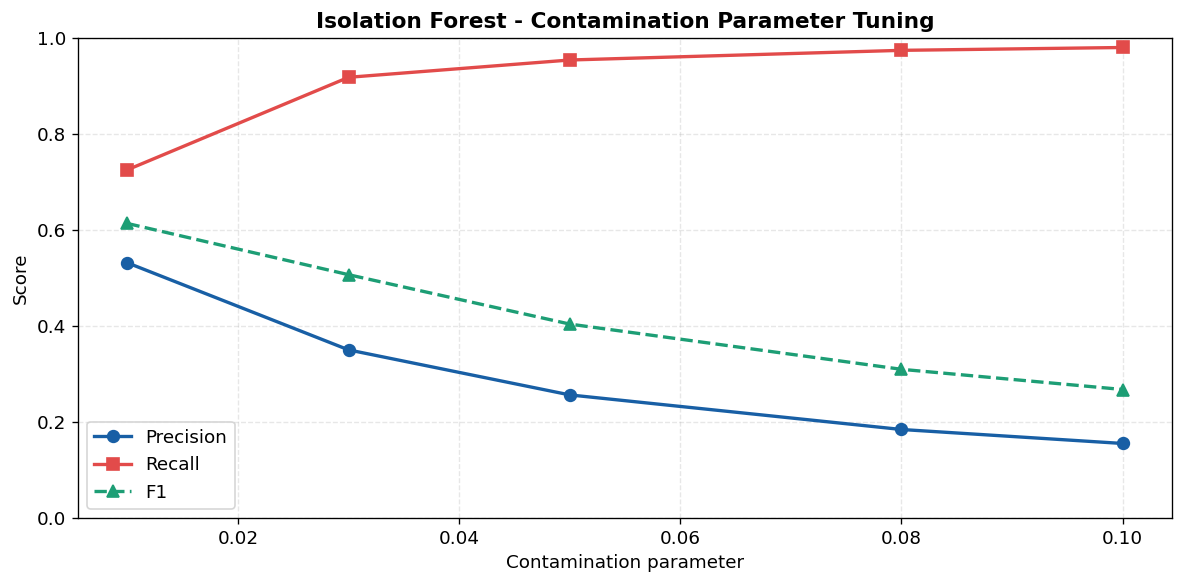


Best contamination by F1: 0.01 (F1=0.613)


In [13]:
contaminations = [0.01, 0.03, 0.05, 0.08, 0.10]
results = []

print('Tuning contamination parameter...')
for c in contaminations:
    m = IsolationForest(n_estimators=100, contamination=c,
                        random_state=42, n_jobs=-1)
    m.fit(X_train)
    preds  = (m.predict(X_test) == -1).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    prec = precision_score(y_true_test, preds, zero_division=0)
    rec  = recall_score(y_true_test, preds, zero_division=0)
    f1   = f1_score(y_true_test, preds, zero_division=0)
    n_anom = preds.sum()
    results.append({'contamination':c,'precision':prec,'recall':rec,
                    'f1':f1,'n_anomalies':n_anom})
    print(f'  c={c:.2f} -> precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}  anomalies={n_anom:,}')

res_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df['contamination'], res_df['precision'], 'o-',
        color='#185FA5', linewidth=2, label='Precision', markersize=7)
ax.plot(res_df['contamination'], res_df['recall'], 's-',
        color='#E24B4A', linewidth=2, label='Recall', markersize=7)
ax.plot(res_df['contamination'], res_df['f1'], '^--',
        color='#1D9E75', linewidth=2, label='F1', markersize=7)
ax.set_xlabel('Contamination parameter')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest - Contamination Parameter Tuning')
ax.legend(); ax.set_ylim(0,1)
plt.tight_layout()
save_fig(fig, '12_contamination_tuning')

best_row = res_df.loc[res_df['f1'].idxmax()]
print(f'\nBest contamination by F1: {best_row["contamination"]} (F1={best_row["f1"]:.3f})')


## 9. Save Models & Scored Dataset

In [14]:
# Save Isolation Forest
if_artifact = {
    'model'        : IF_model,
    'scaler'       : scaler,
    'feature_cols' : FEATURE_COLS,
    'contamination': 0.05,
    'n_estimators' : 200,
}
joblib.dump(if_artifact, f'{MODELS_DIR}/isolation_forest.pkl')
print('Saved -> models/isolation_forest.pkl')

# Save One-Class SVM
svm_artifact = {
    'model'        : SVM_model,
    'scaler'       : scaler,
    'feature_cols' : FEATURE_COLS,
}
joblib.dump(svm_artifact, f'{MODELS_DIR}/one_class_svm.pkl')
print('Saved -> models/one_class_svm.pkl')

# Save scored dataset (untuk dashboard)
KEEP_COLS = [
    'datetime','machineID','model','age',
    'volt','rotate','pressure','vibration',
    'if_score','if_anomaly','if_anomaly_01',
    'health_score','health_status',
    'hours_to_failure','will_fail_24h','will_fail_48h','failure_type',
    'total_error_count24h','days_since_maint'
] + [f'{s}_mean24h' for s in ['volt','rotate','pressure','vibration']]

df_scored = df[KEEP_COLS].copy()
df_scored.to_parquet(f'{PROC_DIR}/scored.parquet', index=False)
print(f'Saved -> data/processed/scored.parquet ({df_scored.shape})')

print('\nAll models saved. Next: Notebook 04 - Streamlit Dashboard')


Saved -> models/isolation_forest.pkl
Saved -> models/one_class_svm.pkl


Saved -> data/processed/scored.parquet ((876100, 23))

All models saved. Next: Notebook 04 - Streamlit Dashboard


## 10. Model Summary

In [15]:
print('='*55)
print('MODEL DEVELOPMENT SUMMARY')
print('='*55)
print(f'Features used       : {len(FEATURE_COLS)}')
print(f'Training samples    : {len(X_train):,} (normal data only)')
print(f'Test samples        : {len(X_test):,}')
print()
print('ISOLATION FOREST')
print(f'  n_estimators      : 200')
print(f'  contamination     : 0.05')
print()
print('HEALTH SCORE')
latest = df.groupby('machineID')['health_score'].last()
print(f'  Critical machines : {(df.groupby("machineID")["health_status"].last() == "Critical").sum()}')
print(f'  Warning machines  : {(df.groupby("machineID")["health_status"].last() == "Warning").sum()}')
print(f'  Healthy machines  : {(df.groupby("machineID")["health_status"].last() == "Healthy").sum()}')
print()
print('ARTIFACTS SAVED')
print('  models/isolation_forest.pkl')
print('  models/one_class_svm.pkl')
print('  models/scaler.pkl')
print('  models/feature_cols.json')
print('  data/processed/features.parquet')
print('  data/processed/scored.parquet')
print()
print('Next step -> Notebook 04 / dashboard/app.py: Streamlit Dashboard')


MODEL DEVELOPMENT SUMMARY
Features used       : 44
Training samples    : 615,203 (normal data only)
Test samples        : 221,500

ISOLATION FOREST
  n_estimators      : 200
  contamination     : 0.05

HEALTH SCORE
  Critical machines : 3
  Warning machines  : 27
  Healthy machines  : 70

ARTIFACTS SAVED
  models/isolation_forest.pkl
  models/one_class_svm.pkl
  models/scaler.pkl
  models/feature_cols.json
  data/processed/features.parquet
  data/processed/scored.parquet

Next step -> Notebook 04 / dashboard/app.py: Streamlit Dashboard
